## Очистка (ETL)

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
BLUE, ORANGE, AQUA, GRAY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#e34948"
plt.rcParams.update({"figure.figsize": (11, 3.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.edgecolor": "#8a8984",
                     "lines.linewidth": 2, "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "legend.frameon": False, "date.converter": "concise", "xtick.labelsize": 8})

from demand_forecasting import data as D
raw = D.load_raw("../data")
sales = raw["sales"][D.KEY + ["qty"]].copy(); sales["qty"] = sales["qty"].astype(float)
END = sales["period"].max()
log = []
print(len(sales), "строк на входе")

1526 строк на входе


## Дубли и отрицательные значения

In [2]:
df, i = D.drop_duplicates(sales); log += i
print("после дублей:", len(df), "| найдено:", len(i))
df, i = D.mask_negative(df); log += i
print(pd.DataFrame(i)[["sku", "period", "issue", "action", "old"]].to_string(index=False))

после дублей: 1523 | найдено: 3
     sku  period        issue action  old
SKU_0014 2024-06 negative_qty masked -8.0


## Полный календарь

In [3]:
df, i = D.reindex_calendar(df, END); log += i
print(pd.DataFrame(i)[["sku", "period", "issue", "action"]].to_string(index=False))
df = df[df["active"]].drop(columns="active")
print("\nстрок:", len(df), "| рядов:", df.groupby(D.SERIES).ngroups, "| NaN:", int(df.qty.isna().sum()))

     sku  period           issue   action
SKU_0005 2023-07     missing_row   masked
SKU_0005 2023-08     missing_row   masked
SKU_0005 2024-08     missing_row   masked
SKU_0005 2025-05     missing_row   masked
SKU_0011 2024-09 inactive_series excluded

строк: 1506 | рядов: 45 | NaN: 5


## Смена единицы учёта

     sku  period      issue               action
SKU_0018 2024-07 unit_shift history_before_x1000


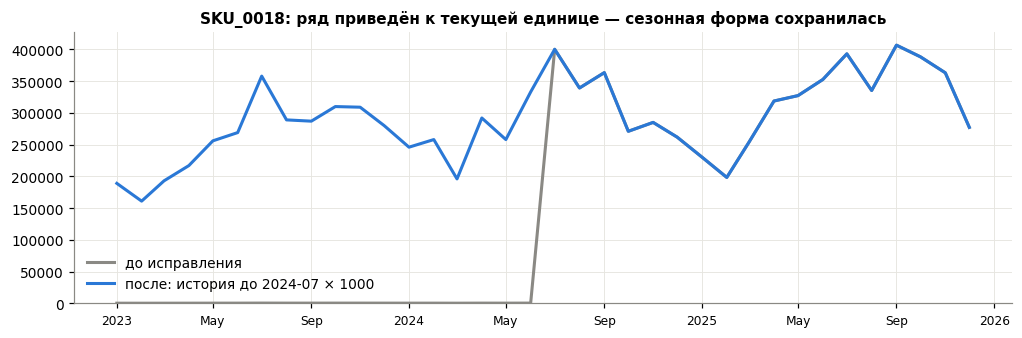

In [4]:
before = df[df.sku == "SKU_0018"].qty.to_numpy()
df, i = D.fix_unit_shift(df); log += i
print(pd.DataFrame(i)[["sku", "period", "issue", "action"]].to_string(index=False))
after = df[df.sku == "SKU_0018"].qty.to_numpy()
fig, ax = plt.subplots()
t = df[df.sku == "SKU_0018"].period.dt.to_timestamp()
ax.plot(t, before, color=GRAY, label="до исправления"); ax.plot(t, after, color=BLUE, label="после: история до 2024-07 × 1000")
ax.set_title("SKU_0018: ряд приведён к текущей единице — сезонная форма сохранилась"); ax.legend(); ax.set_ylim(0); plt.show()

## Маски

In [5]:
df, i = D.mask_stockouts(df, raw["stock"]); log += i; print("OOS замаскировано:", len(i))
df, i = D.mask_promo(df, raw["promo"]);     log += i; print("промо замаскировано:", len(i))
print("\nNaN по причинам:\n", df[df.qty.isna()].flag.value_counts().to_string())

OOS замаскировано: 10
промо замаскировано: 8

NaN по причинам:
 flag
stockout       10
promo           8
missing_row     4
negative        1


## Импутация

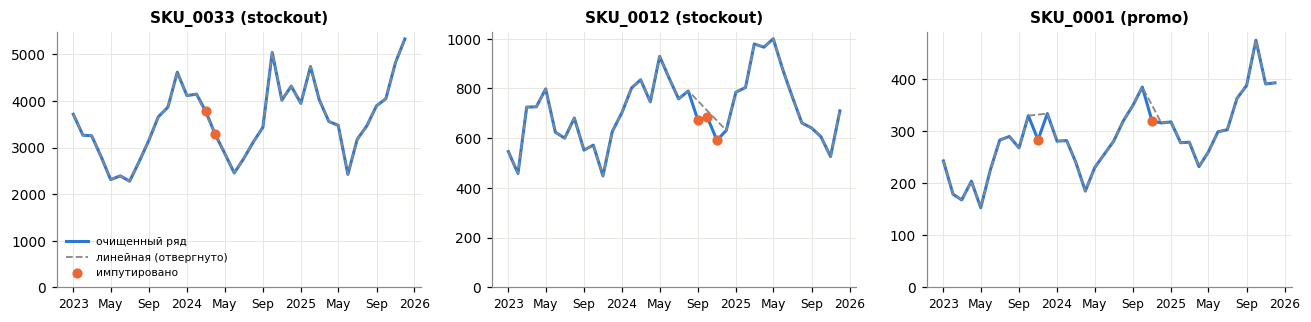

In [6]:
masked = df.copy()
df, i = D.impute(df); log += i
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, sku in zip(axes, ["SKU_0033", "SKU_0012", "SKU_0001"]):
    g, gm = df[df.sku == sku], masked[masked.sku == sku]
    t = g.period.dt.to_timestamp()
    ax.plot(t, g.qty, color=BLUE, label="очищенный ряд")
    ax.plot(t, gm.qty.interpolate(limit_direction="both"), color=GRAY, lw=1.2, ls="--", label="линейная (отвергнуто)")
    ax.scatter(t[~g.observed], g.qty[~g.observed], color=ORANGE, s=32, zorder=3, label="импутировано")
    ax.set_title(f"{sku} ({', '.join(sorted(set(gm.flag[gm.qty.isna()])))})"); ax.set_ylim(0)
axes[0].legend(fontsize=7); plt.tight_layout(); plt.show()

## Итог

In [7]:
clean, issues = D.clean(raw)
assert np.allclose(clean.qty.to_numpy(), df.qty.to_numpy())          # пошаговый путь = D.clean()
print("рядов:", clean.groupby(D.SERIES).ngroups, "| строк:", len(clean), "| импутировано:", int((~clean.observed).sum()))
print(issues.issue.value_counts().to_string())

рядов: 45 | строк: 1506 | импутировано: 23
issue
imputed            23
stockout           10
promo               8
missing_row         4
exact_duplicate     3
negative_qty        1
inactive_series     1
unit_shift          1
